
# Evaluation of outlier detection estimators

This example compares two outlier detection algorithms, namely
`local_outlier_factor` (LOF) and `isolation_forest` (IForest), on
real-world datasets available in :class:`sklearn.datasets`. The goal is to show
that different algorithms perform well on different datasets and contrast their
training speed and sensitivity to hyperparameters.

The algorithms are trained (without labels) on the whole dataset assumed to
contain outliers.

1. The ROC curves are computed using knowledge of the ground-truth labels
   and displayed using :class:`~sklearn.metrics.RocCurveDisplay`.

2. The performance is assessed in terms of the ROC-AUC.


In [303]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

## Dataset preprocessing and model training

Different outlier detection models require different preprocessing. In the
presence of categorical variables,
:class:`~sklearn.preprocessing.OrdinalEncoder` is often a good strategy for
tree-based models such as :class:`~sklearn.ensemble.IsolationForest`, whereas
neighbors-based models such as :class:`~sklearn.neighbors.LocalOutlierFactor`
would be impacted by the ordering induced by ordinal encoding. To avoid
inducing an ordering, on should rather use
:class:`~sklearn.preprocessing.OneHotEncoder`.

Neighbors-based models may also require scaling of the numerical features (see
for instance `neighbors_scaling`). In the presence of outliers, a good
option is to use a :class:`~sklearn.preprocessing.RobustScaler`.



### Create an outlier detection estimator based on its name
    

In [304]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
)



### KDDCup99 - SA dataset

The `kddcup99_dataset` was generated using a closed network and
hand-injected attacks. The SA dataset is a subset of it obtained by simply
selecting all the normal data and an anomaly proportion of around 3%.



In [305]:
import numpy as np

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split

X, y = fetch_kddcup99(
    subset="SA", percent10=True, random_state=42, return_X_y=True, as_frame=True
)
y = (y != b"normal.").astype(np.int32)
X, _, y, _ = train_test_split(X, y, train_size=0.1, stratify=y, random_state=42)
y = np.where(y == 1, 0, 1)
n_samples, anomaly_frac = X.shape[0], y.mean()
print(f"{n_samples} datapoints with {y.sum()} anomalies ({anomaly_frac:.02%})")

10065 datapoints with 9727 anomalies (96.64%)


In [306]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def preprocessing(dataframe, robustscaler_flag):
    one_hot_columns = []
    ordinal_columns = []
    for col in dataframe.select_dtypes(include=["object", 'category']).columns:
        num_unique_values = dataframe[col].nunique()
        if num_unique_values < 10:
            one_hot_columns.append(col)
        else:
            ordinal_columns.append(col)
    num_columns = dataframe.select_dtypes(exclude=["object", 'category']).columns
    pip = create_pipeline(
        one_hot_columns=one_hot_columns,
        ordinal_columns=ordinal_columns,
        scaling_columns=num_columns,
        robustscaler=robustscaler_flag
    )
    return pip

def create_pipeline(one_hot_columns=None, ordinal_columns=None, scaling_columns=None, robustscaler = True):
    transformers = []
    if one_hot_columns is not None:
        transformers.append(
            ("onehot", OneHotEncoder(handle_unknown="ignore"), one_hot_columns)
        )
    if ordinal_columns is not None:
        transformers.append(
            ("ordinal", OrdinalEncoder(), ordinal_columns)
        )
    if scaling_columns is not None:
        transformers.append(
            ("scaler", RobustScaler() if robustscaler else StandardScaler(), scaling_columns)
        )
    return ColumnTransformer(transformers, remainder="passthrough")

def create_model(model, X, robustscaler_flag = True):
    pipeline = preprocessing(X, robustscaler_flag=robustscaler_flag)
    return Pipeline([
    ("preprocessing", pipeline),
    ("model", model)
])

In [307]:
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

models = {
    "Isolation Forest": IsolationForest(),
    "Local Outlier Factor": LocalOutlierFactor(novelty=True),
}

def models_bench(models, X, y, robustscaler_flag = True):
    results = {}
    for model_name, model in models.items():
            for robustscaler_flag in [True, False]:
                model_suffix = " with RobustScaler" if robustscaler_flag else " with StandardScaler"
                full_model_name = model_name + model_suffix
                clf = create_model(model, X, robustscaler_flag=robustscaler_flag)
                clf.fit(X)
                scores = clf.decision_function(X)
                auc = roc_auc_score(y, scores)
                fpr, tpr, th = roc_curve(y, scores)
                display = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc=auc)
                results[full_model_name] = auc
                results[full_model_name + " display"] = display
    return results

In [308]:
def plots(res):
    i = 0
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    for model_name, display in res.items():
        if "display" in model_name:
            print(f"{model_name.replace(' display', '')} AUC: {res[model_name.replace(' display', '')]:.4f}")
            display.plot(ax=ax, label = model_name.replace(" display", ""))
    plt.show()
    plt.tight_layout()


Isolation Forest(K=100) with RobustScaler AUC: 0.9650
Isolation Forest(K=100) with StandardScaler AUC: 0.9606
Isolation Forest(K=200) with RobustScaler AUC: 0.9502
Isolation Forest(K=200) with StandardScaler AUC: 0.9555
Isolation Forest(K=50) with RobustScaler AUC: 0.9441
Isolation Forest(K=50) with StandardScaler AUC: 0.9468


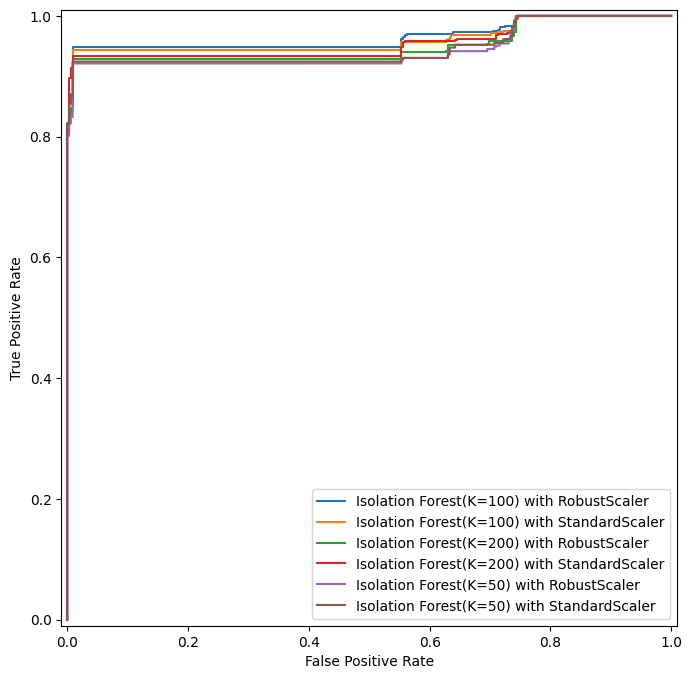

<Figure size 640x480 with 0 Axes>

In [309]:
models = {
    "Isolation Forest(K=100)": IsolationForest(n_estimators=100),
    "Isolation Forest(K=200)": IsolationForest(n_estimators=200),
    "Isolation Forest(K=50)": IsolationForest(n_estimators=50),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

LocalOutlierFactor(K=20) with RobustScaler AUC: 0.4035
LocalOutlierFactor(K=20) with StandardScaler AUC: 0.4035
LocalOutlierFactor(K=50) with RobustScaler AUC: 0.4963
LocalOutlierFactor(K=50) with StandardScaler AUC: 0.4963
LocalOutlierFactor(K=100) with RobustScaler AUC: 0.5974
LocalOutlierFactor(K=100) with StandardScaler AUC: 0.5974


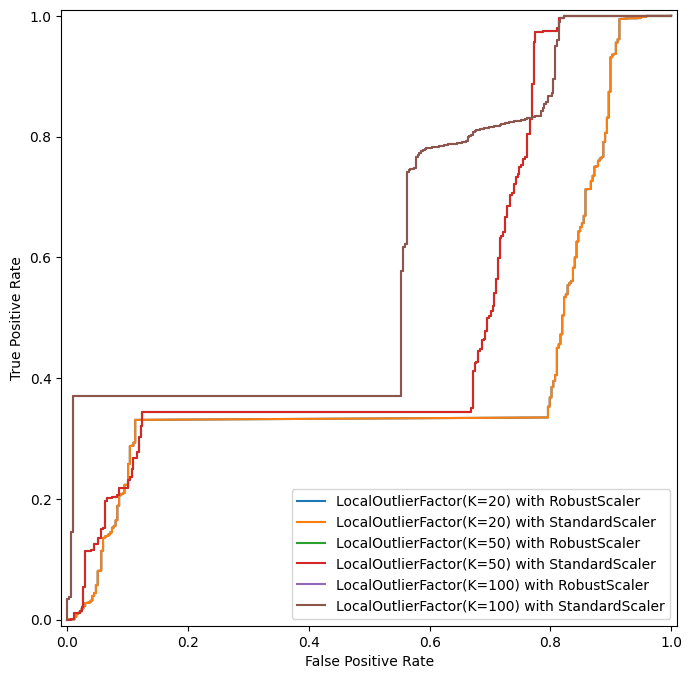

<Figure size 640x480 with 0 Axes>

In [310]:
models = {
    'LocalOutlierFactor(K=20)': LocalOutlierFactor(n_neighbors=20, novelty=True),
    'LocalOutlierFactor(K=50)': LocalOutlierFactor(n_neighbors=50, novelty=True),
    'LocalOutlierFactor(K=100)': LocalOutlierFactor(n_neighbors=100, novelty=True),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

### Forest covertypes dataset

The `covtype_dataset` is a multiclass dataset where the target is the
dominant species of tree in a given patch of forest. It contains 54 features,
some of which ("Wilderness_Area" and "Soil_Type") are already binary encoded.
Though originally meant as a classification task, one can regard inliers as
samples encoded with label 2 and outliers as those with label 4.



In [311]:
from sklearn.datasets import fetch_covtype

X, y = fetch_covtype(return_X_y=True, as_frame=True)
s = (y == 2) + (y == 4)
X = X.loc[s]
y = y.loc[s]
y = (y != 2).astype(np.int32)
X, _, y, _ = train_test_split(X, y, train_size=0.05, stratify=y, random_state=42)
X_forestcover = X  # save X for later use
y = np.where(y == 1, 0, 1)  
n_samples, anomaly_frac = X.shape[0], y.mean()
print(f"{n_samples} datapoints with {y.sum()} anomalies ({anomaly_frac:.02%})")

14302 datapoints with 14165 anomalies (99.04%)


Isolation Forest(K=100) with RobustScaler AUC: 0.9671
Isolation Forest(K=100) with StandardScaler AUC: 0.9749
Isolation Forest(K=200) with RobustScaler AUC: 0.9881
Isolation Forest(K=200) with StandardScaler AUC: 0.9664
Isolation Forest(K=50) with RobustScaler AUC: 0.9323
Isolation Forest(K=50) with StandardScaler AUC: 0.9711


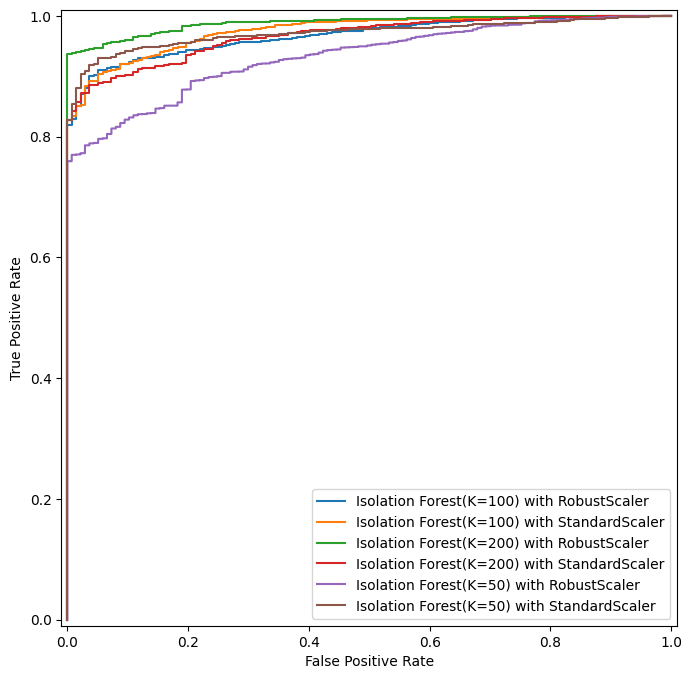

<Figure size 640x480 with 0 Axes>

In [312]:
models = {
    "Isolation Forest(K=100)": IsolationForest(n_estimators=100),
    "Isolation Forest(K=200)": IsolationForest(n_estimators=200),
    "Isolation Forest(K=50)": IsolationForest(n_estimators=50),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

LocalOutlierFactor(K=20) with RobustScaler AUC: 0.4995
LocalOutlierFactor(K=20) with StandardScaler AUC: 0.7376
LocalOutlierFactor(K=50) with RobustScaler AUC: 0.5517
LocalOutlierFactor(K=50) with StandardScaler AUC: 0.5931
LocalOutlierFactor(K=100) with RobustScaler AUC: 0.7908
LocalOutlierFactor(K=100) with StandardScaler AUC: 0.6694


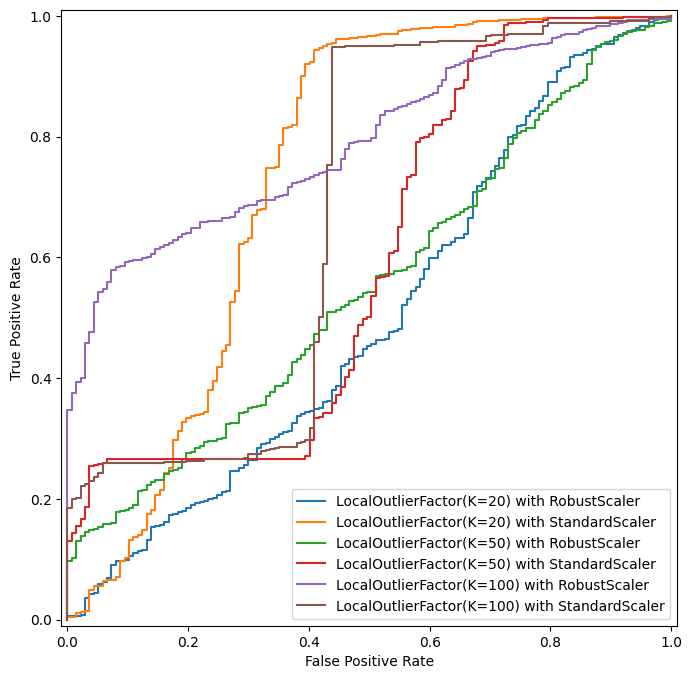

<Figure size 640x480 with 0 Axes>

In [313]:
models = {
    'LocalOutlierFactor(K=20)': LocalOutlierFactor(n_neighbors=20, novelty=True),
    'LocalOutlierFactor(K=50)': LocalOutlierFactor(n_neighbors=50, novelty=True),
    'LocalOutlierFactor(K=100)': LocalOutlierFactor(n_neighbors=100, novelty=True),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

### Ames Housing dataset

The [Ames housing dataset](http://www.openml.org/d/43926) is originally a
regression dataset where the target are sales prices of houses in Ames, Iowa.
Here we convert it into an outlier detection problem by regarding houses with
price over 70 USD/sqft. To make the problem easier, we drop intermediate
prices between 40 and 70 USD/sqft.



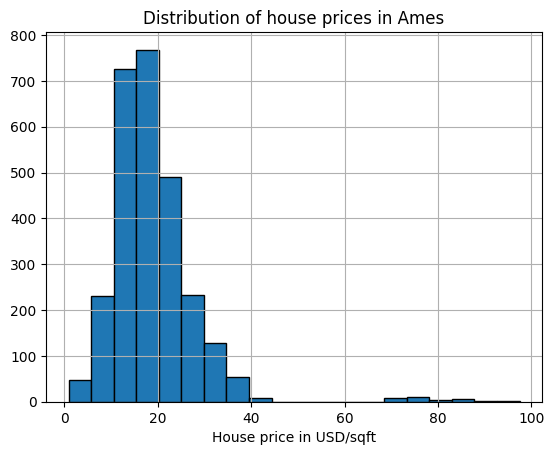

In [314]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

X, y = fetch_openml(name="ames_housing", version=1, return_X_y=True, as_frame=True)
y = y.div(X["Lot_Area"])

# None values in pandas 1.5.1 were mapped to np.nan in pandas 2.0.1
X["Misc_Feature"] = X["Misc_Feature"].cat.add_categories("NoInfo").fillna("NoInfo")
X["Mas_Vnr_Type"] = X["Mas_Vnr_Type"].cat.add_categories("NoInfo").fillna("NoInfo")

X.drop(columns="Lot_Area", inplace=True)
mask = (y < 40) | (y > 70)
X = X.loc[mask]
y = y.loc[mask]
y.hist(bins=20, edgecolor="black")
plt.xlabel("House price in USD/sqft")
_ = plt.title("Distribution of house prices in Ames")

In [315]:
y = (y > 70).astype(np.int32)

n_samples, anomaly_frac = X.shape[0], y.mean()
print(f"{n_samples} datapoints with {y.sum()} anomalies ({anomaly_frac:.02%})")

2714 datapoints with 30 anomalies (1.11%)


In [316]:
y = np.where(y == 1, 0, 1)

The dataset contains 46 categorical features. In this case it is easier use a
:class:`~sklearn.compose.make_column_selector` to find them instead of passing
a list made by hand.



Isolation Forest(K=100) with RobustScaler AUC: 0.6564
Isolation Forest(K=100) with StandardScaler AUC: 0.6213
Isolation Forest(K=200) with RobustScaler AUC: 0.6926
Isolation Forest(K=200) with StandardScaler AUC: 0.6537
Isolation Forest(K=50) with RobustScaler AUC: 0.6301
Isolation Forest(K=50) with StandardScaler AUC: 0.5452


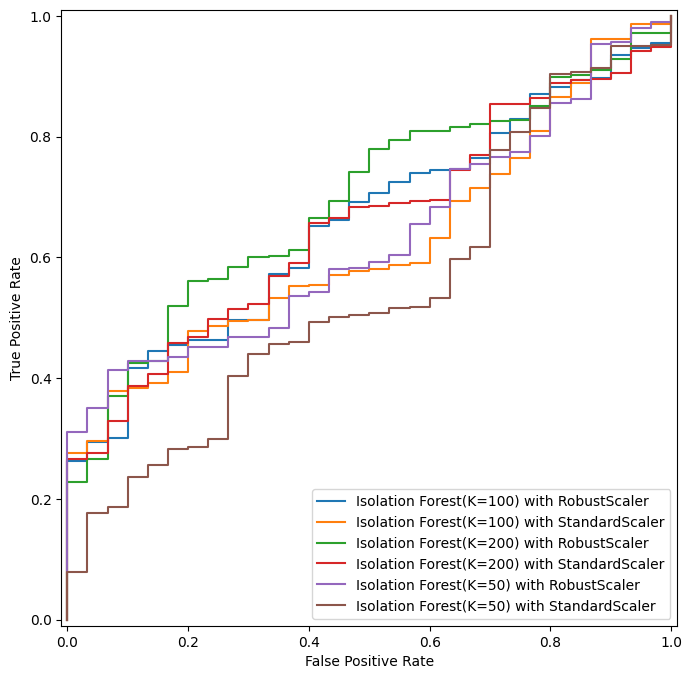

<Figure size 640x480 with 0 Axes>

In [317]:
models = {
    "Isolation Forest(K=100)": IsolationForest(n_estimators=100),
    "Isolation Forest(K=200)": IsolationForest(n_estimators=200),
    "Isolation Forest(K=50)": IsolationForest(n_estimators=50),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

LocalOutlierFactor(K=20) with RobustScaler AUC: 0.5228
LocalOutlierFactor(K=20) with StandardScaler AUC: 0.5687
LocalOutlierFactor(K=50) with RobustScaler AUC: 0.5696
LocalOutlierFactor(K=50) with StandardScaler AUC: 0.5540
LocalOutlierFactor(K=100) with RobustScaler AUC: 0.5562
LocalOutlierFactor(K=100) with StandardScaler AUC: 0.5707


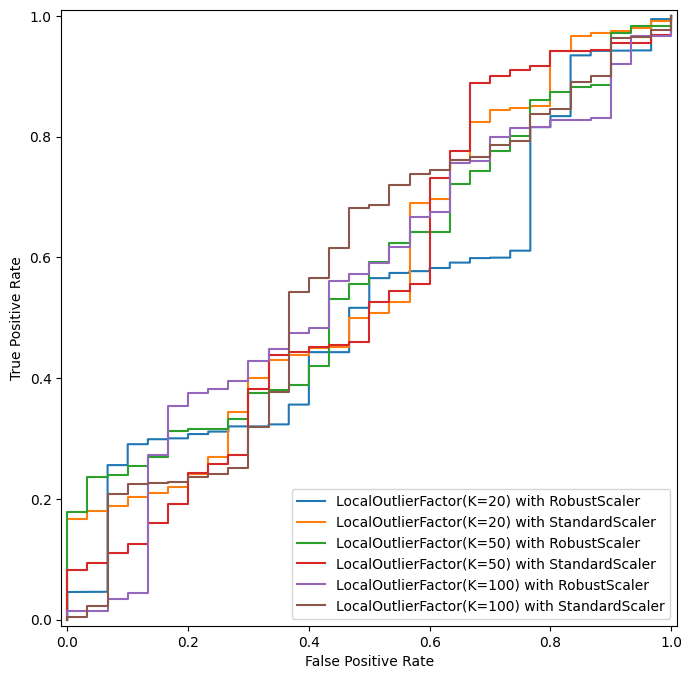

<Figure size 640x480 with 0 Axes>

In [318]:
models = {
    'LocalOutlierFactor(K=20)': LocalOutlierFactor(n_neighbors=20, novelty=True),
    'LocalOutlierFactor(K=50)': LocalOutlierFactor(n_neighbors=50, novelty=True),
    'LocalOutlierFactor(K=100)': LocalOutlierFactor(n_neighbors=100, novelty=True),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

### Cardiotocography dataset

The [Cardiotocography dataset](http://www.openml.org/d/1466) is a multiclass
dataset of fetal cardiotocograms, the classes being the fetal heart rate (FHR)
pattern encoded with labels from 1 to 10. Here we set class 3 (the minority
class) to represent the outliers. It contains 30 numerical features, some of
which are binary encoded and some are continuous.



In [319]:
X, y = fetch_openml(name="cardiotocography", version=1, return_X_y=True, as_frame=True)
X_cardiotocography = X  # save X for later use
s = y == "3"
y = s.astype(np.int32)
y = np.where(y == 1, 0, 1)
n_samples, anomaly_frac = X.shape[0], y.mean()
print(f"{n_samples} datapoints with {y.sum()} anomalies ({anomaly_frac:.02%})")

2126 datapoints with 2073 anomalies (97.51%)


LocalOutlierFactor(K=20) with RobustScaler AUC: 0.7074
LocalOutlierFactor(K=20) with StandardScaler AUC: 0.3402
LocalOutlierFactor(K=50) with RobustScaler AUC: 0.6592
LocalOutlierFactor(K=50) with StandardScaler AUC: 0.2758
LocalOutlierFactor(K=100) with RobustScaler AUC: 0.5781
LocalOutlierFactor(K=100) with StandardScaler AUC: 0.9776


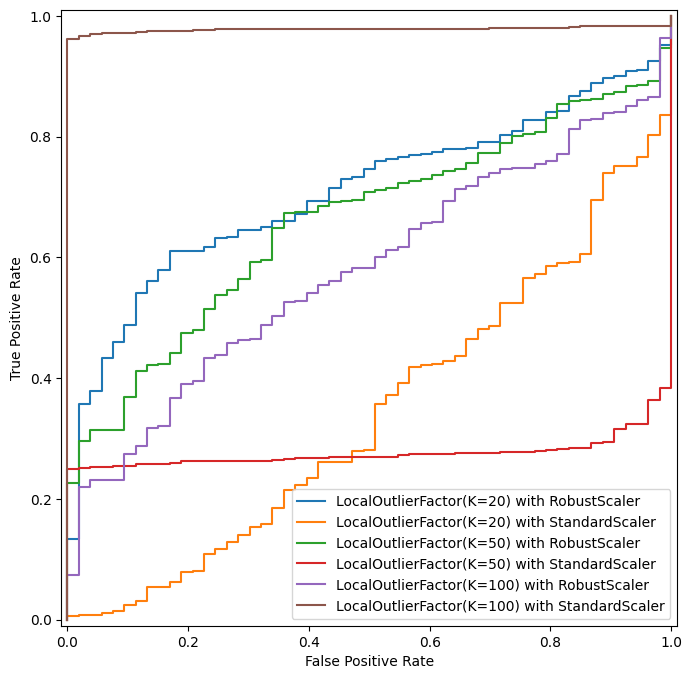

<Figure size 640x480 with 0 Axes>

In [320]:
models = {
    'LocalOutlierFactor(K=20)': LocalOutlierFactor(n_neighbors=20, novelty=True),
    'LocalOutlierFactor(K=50)': LocalOutlierFactor(n_neighbors=50, novelty=True),
    'LocalOutlierFactor(K=100)': LocalOutlierFactor(n_neighbors=100, novelty=True),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

Isolation Forest(K=100) with RobustScaler AUC: 0.8458
Isolation Forest(K=100) with StandardScaler AUC: 0.5982
Isolation Forest(K=200) with RobustScaler AUC: 0.6516
Isolation Forest(K=200) with StandardScaler AUC: 0.6177
Isolation Forest(K=50) with RobustScaler AUC: 0.6801
Isolation Forest(K=50) with StandardScaler AUC: 0.7087


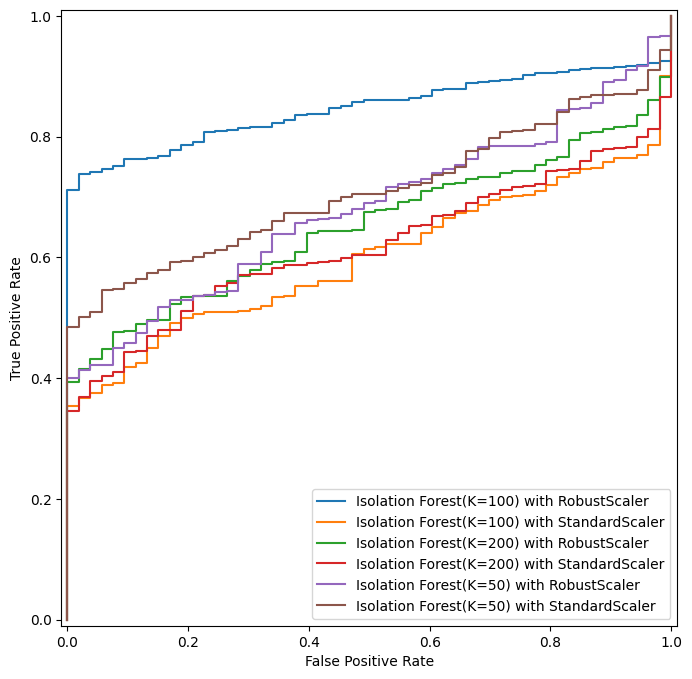

<Figure size 640x480 with 0 Axes>

In [321]:
models = {
    "Isolation Forest(K=100)": IsolationForest(n_estimators=100),
    "Isolation Forest(K=200)": IsolationForest(n_estimators=200),
    "Isolation Forest(K=50)": IsolationForest(n_estimators=50),
}

res = models_bench(models, X, y, robustscaler_flag=True)
plots(res)

## Plot and interpret results

The algorithm performance relates to how good the true positive rate (TPR) is
at low value of the false positive rate (FPR). The best algorithms have the
curve on the top-left of the plot and the area under curve (AUC) close to 1.
The diagonal dashed line represents a random classification of outliers and
inliers.



## Ablation study

In this section we explore the impact of the hyperparameter `n_neighbors` and
the choice of scaling the numerical variables on the LOF model. Here we use
the `covtype_dataset` dataset as the binary encoded categories introduce
a natural scale of euclidean distances between 0 and 1. We then want a scaling
method to avoid granting a privilege to non-binary features and that is robust
enough to outliers so that the task of finding them does not become too
difficult.



On the one hand, :class:`~sklearn.preprocessing.RobustScaler` scales each
feature independently by using the interquartile range (IQR) by default, which
is the range between the 25th and 75th percentiles of the data. It centers the
data by subtracting the median and then scale it by dividing by the IQR. The
IQR is robust to outliers: the median and interquartile range are less
affected by extreme values than the range, the mean and the standard
deviation. Furthermore, :class:`~sklearn.preprocessing.RobustScaler` does not
squash marginal outlier values, contrary to
:class:`~sklearn.preprocessing.StandardScaler`.

On the other hand, :class:`~sklearn.preprocessing.MinMaxScaler` scales each
feature individually such that its range maps into the range between zero and
one. If there are outliers in the data, they can skew it towards either the
minimum or maximum values, leading to a completely different distribution of
data with large marginal outliers: all non-outlier values can be collapsed
almost together as a result.

:class:`~sklearn.preprocessing.StandardScaler` and
:class:`~sklearn.preprocessing.SplineTransformer`. Please refer to their
respective documentation for more details.



### Try same for different datasets